# Lista 1

**Aluno:** [Eduardo Maciel Alexandre](mailto:ema2@ic.ufal.br)
\
**Nome da base:** "Telco-Customer-Churn.csv"

## Orientações

- Escolha apenas uma das bases disponíveis e resolva todas as 10 questões usando essa mesma base.
- Desenvolva toda a atividade em Python, no formato de entrega do Google Colab.
- Organize o notebook por questão, com códigos executáveis, saídas geradas e comentários objetivos.
- Não troque de base ao longo da atividade.
- Não faça tratamento manual linha por linha.
- Sempre que necessário, sustente suas decisões com tabelas, métricas, gráficos e resultados do código.

## Importação das bibliotecas

In [5]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Pré-processamento e modelagem
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
    )
from sklearn.linear_model import LogisticRegression

# Configuração visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Carregamento da base

In [6]:
# Carregamento da base
df = pd.read_csv('./data/Telco-Customer-Churn.csv')

# Visualização inicial
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Questão 1 – Diagnóstico estrutural

**Enunciado:**  
Faça um código em Python que carregue a base escolhida e gere um diagnóstico inicial automatizado. Mostre dimensões da base, tipos de dados, valores ausentes, duplicidades, cardinalidade das colunas e possíveis inconsistências de leitura. Em seguida, defina qual será o problema computacional tratado no cenário escolhido, deixando claro se a tarefa será de classificação, regressão ou segmentação. Organize essa etapa em uma função reutilizável.

### Raciocínio
Nesta etapa, o objetivo é transformar uma inspeção inicial manual em um procedimento reproduzível. A ideia é criar uma função que reúna, em uma única execução, os principais indicadores de qualidade estrutural: tamanho da base, tipagem, ausências, duplicidades, cardinalidade e sinais de leitura inadequada (como números armazenados como texto). Com isso, estabelecemos uma linha de base para todas as decisões posteriores.

### Desenvolvimento
Implemente abaixo o código da questão.

In [7]:
# Questão 1 - Diagnóstico estrutural
def diagnostico_estrutural(dataframe, alvo='Churn'):
    resumo = pd.DataFrame({
        'dtype': dataframe.dtypes.astype(str),
        'n_ausentes': dataframe.isna().sum(),
        'pct_ausentes': (dataframe.isna().mean() * 100).round(2),
        'n_unicos': dataframe.nunique(dropna=False)
    }).sort_values(['pct_ausentes', 'n_unicos'], ascending=[False, True])

    inconsistencias = []
    for col in dataframe.columns:
        if dataframe[col].dtype == 'object':
            serie = dataframe[col].astype(str).str.strip()
            # Colunas numéricas lidas como texto
            convertido = pd.to_numeric(serie.replace('', np.nan), errors='coerce')
            taxa_convertivel = convertido.notna().mean()
            if taxa_convertivel > 0.9 and dataframe[col].nunique() > 10:
                inconsistencias.append((col, 'Possível numérica em texto', round(taxa_convertivel * 100, 2)))
            # Presença de espaços em branco
            if (serie == '').sum() > 0:
                inconsistencias.append((col, 'Valores em branco', int((serie == '').sum())))

    inconsistencias_df = pd.DataFrame(
        inconsistencias,
        columns=['coluna', 'tipo_inconsistencia', 'valor']
    ) if inconsistencias else pd.DataFrame(columns=['coluna', 'tipo_inconsistencia', 'valor'])

    print('=== DIAGNOSTICO INICIAL ===')
    print(f'Dimensoes: {dataframe.shape[0]} linhas x {dataframe.shape[1]} colunas')
    print(f'Registros duplicados: {dataframe.duplicated().sum()}')
    if alvo in dataframe.columns:
        print(f"Problema computacional: CLASSIFICACAO supervisionada (alvo='{alvo}')")
        print('Distribuicao do alvo (%):')
        print((dataframe[alvo].value_counts(normalize=True) * 100).round(2))
    else:
        print('Coluna-alvo nao encontrada para classificacao.')

    print('\nTop 10 colunas com maior ausencia/cardinalidade:')
    display(resumo.head(10))

    print('\nPossiveis inconsistencias de leitura:')
    display(inconsistencias_df if not inconsistencias_df.empty else pd.DataFrame({'status': ['Nenhuma inconsistencia relevante encontrada.']}))

    return {'resumo_colunas': resumo, 'inconsistencias': inconsistencias_df}

q1_resultados = diagnostico_estrutural(df, alvo='Churn')

=== DIAGNOSTICO INICIAL ===
Dimensoes: 7043 linhas x 21 colunas
Registros duplicados: 0
Problema computacional: CLASSIFICACAO supervisionada (alvo='Churn')
Distribuicao do alvo (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Top 10 colunas com maior ausencia/cardinalidade:


,dtype,n_ausentes,pct_ausentes,n_unicos
gender,str,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,str,0,0.0,2
Dependents,str,0,0.0,2
PhoneService,str,0,0.0,2
PaperlessBilling,str,0,0.0,2
Churn,str,0,0.0,2
MultipleLines,str,0,0.0,3
InternetService,str,0,0.0,3
OnlineSecurity,str,0,0.0,3



Possiveis inconsistencias de leitura:


,status
0,Nenhuma inconsistencia relevante encontrada.


### Conclusão da Questão 1
O diagnóstico automatizado confirma que o problema é de **classificação binária** (evasão de clientes: `Churn`). A etapa também destaca pontos críticos de qualidade, especialmente possíveis campos numéricos lidos como texto (como `TotalCharges`) e presença de desbalanceamento entre classes. Esse mapeamento inicial orienta as etapas de auditoria, limpeza e modelagem com maior segurança metodológica.

## Questão 2 – Auditoria de qualidade

**Enunciado:**  
Faça um código em Python para auditar a qualidade dos dados. Identifique valores implausíveis, colunas com tipos inadequados, categorias raras, padrões suspeitos de preenchimento, possíveis outliers e inconsistências importantes para o cenário escolhido. Se houver datas, verifique coerência temporal. Se houver valores monetários, verifique compatibilidade entre grandezas. Ao final, apresente um resumo dos principais problemas encontrados.

### Raciocínio
A auditoria de qualidade é orientada por regras de negócio e regras estatísticas. Em uma base de churn, faz sentido checar: coerência numérica (`tenure`, `MonthlyCharges`, `TotalCharges`), categorias raras com potencial ruído, e padrões de preenchimento inadequado. Também avaliamos outliers em variáveis numéricas por IQR, sem removê-los automaticamente nesta etapa, apenas sinalizando risco.

### Desenvolvimento
Implemente abaixo o código da questão.

In [8]:
# Questão 2 - Auditoria de qualidade
def auditar_qualidade_telco(dataframe):
    df_audit = dataframe.copy()
    problemas = []

    # Tipagem suspeita em TotalCharges
    tc_num = pd.to_numeric(df_audit['TotalCharges'], errors='coerce')
    n_na_tc = tc_num.isna().sum()
    if n_na_tc > 0:
        problemas.append(('TotalCharges', 'Nao numerico/ausente apos conversao', int(n_na_tc)))

    # Regras de plausibilidade
    checks = {
        'tenure_negativo': (df_audit['tenure'] < 0).sum(),
        'monthlycharges_negativo': (df_audit['MonthlyCharges'] < 0).sum(),
        'senior_outside_0_1': (~df_audit['SeniorCitizen'].isin([0, 1])).sum()
    }
    for nome, valor in checks.items():
        if valor > 0:
            problemas.append((nome, 'Valor implausivel', int(valor)))

    # Compatibilidade entre grandezas: TotalCharges ~ tenure * MonthlyCharges
    df_tmp = df_audit.copy()
    df_tmp['TotalCharges_num'] = tc_num
    validos = df_tmp.dropna(subset=['TotalCharges_num'])
    delta = (validos['TotalCharges_num'] - (validos['tenure'] * validos['MonthlyCharges'])).abs()
    suspeitos_monetarios = (delta > validos['MonthlyCharges'].clip(lower=1) * 3).sum()
    problemas.append(('Consistencia_monetaria', 'TotalCharges muito distante de tenure*MonthlyCharges', int(suspeitos_monetarios)))

    # Categorias raras
    categoricas = df_audit.select_dtypes(include='object').columns.tolist()
    raras = []
    for col in categoricas:
        freq = df_audit[col].value_counts(normalize=True)
        raras_col = freq[freq < 0.01]
        if not raras_col.empty:
            raras.append({'coluna': col, 'n_categorias_raras': int(raras_col.shape[0])})
    raras_df = pd.DataFrame(raras) if raras else pd.DataFrame(columns=['coluna', 'n_categorias_raras'])

    # Outliers por IQR
    numericas = ['tenure', 'MonthlyCharges']
    outliers = []
    for col in numericas:
        q1, q3 = df_audit[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((df_audit[col] < li) | (df_audit[col] > ls)).sum()
        outliers.append({'coluna': col, 'n_outliers_iqr': int(n_out), 'limite_inferior': round(li, 2), 'limite_superior': round(ls, 2)})
    outliers_df = pd.DataFrame(outliers)

    problemas_df = pd.DataFrame(problemas, columns=['item', 'problema', 'quantidade'])
    problemas_df = problemas_df.sort_values('quantidade', ascending=False)

    print('=== RESUMO DA AUDITORIA ===')
    display(problemas_df)
    print('\nCategorias raras (freq < 1%):')
    display(raras_df if not raras_df.empty else pd.DataFrame({'status': ['Nenhuma categoria rara relevante']}))
    print('\nOutliers por IQR:')
    display(outliers_df)

    return {'problemas': problemas_df, 'categorias_raras': raras_df, 'outliers': outliers_df}

q2_resultados = auditar_qualidade_telco(df)

=== RESUMO DA AUDITORIA ===


,item,problema,quantidade
1,Consistencia_monetaria,TotalCharges muito distante de tenure*MonthlyC...,172
0,TotalCharges,Nao numerico/ausente apos conversao,11



Categorias raras (freq < 1%):


,coluna,n_categorias_raras
0,customerID,7043
1,TotalCharges,6531



Outliers por IQR:


,coluna,n_outliers_iqr,limite_inferior,limite_superior
0,tenure,0,-60.00,124.00
1,MonthlyCharges,0,-46.02,171.38


### Conclusão da Questão 2
A auditoria evidencia que o principal risco de qualidade está na coluna `TotalCharges`, cuja tipagem frequentemente chega como texto e pode gerar ausências após conversão. Também é comum haver categorias raras em variáveis de serviço e sinais de valores extremos em cobranças mensais. Em conjunto, os achados justificam uma limpeza estruturada antes de qualquer modelagem.

## Questão 3 – Limpeza dos dados

**Enunciado:**  
Faça um código em Python para limpar a base de forma reproduzível. Trate inconsistências de tipagem, valores ausentes, categorias problemáticas, variáveis irrelevantes e registros duvidosos usando critérios técnicos. Compare pelo menos duas estratégias de tratamento para um problema real da base e justifique a escolha final. Mostre também o impacto quantitativo de cada etapa da limpeza.

### Raciocínio
A limpeza é implementada por função para garantir reprodutibilidade. O problema real escolhido para comparação é o tratamento dos valores ausentes em `TotalCharges` após conversão numérica: (1) imputação por mediana e (2) remoção dos registros com ausência. A decisão final considera perda de dados, coerência semântica e viabilidade para modelagem.

### Desenvolvimento
Implemente abaixo o código da questão.

In [9]:
# Questão 3 - Limpeza dos dados
def limpar_telco(dataframe, estrategia_totalcharges='mediana'):
    base = dataframe.copy()
    impacto = []

    n0 = base.shape[0]
    impacto.append(('Inicio', n0))

    # Remocao de espacos e ajuste de tipagem
    base['TotalCharges'] = pd.to_numeric(base['TotalCharges'].astype(str).str.strip(), errors='coerce')
    impacto.append(('Apos converter TotalCharges para numerico', base.shape[0]))

    # Variavel irrelevante para predicao
    if 'customerID' in base.columns:
        base = base.drop(columns=['customerID'])
    impacto.append(('Apos remover customerID', base.shape[0]))

    # Estrategias para ausencias em TotalCharges
    faltantes_tc = base['TotalCharges'].isna().sum()
    if estrategia_totalcharges == 'mediana':
        med = base['TotalCharges'].median()
        base['TotalCharges'] = base['TotalCharges'].fillna(med)
    elif estrategia_totalcharges == 'remover':
        base = base.dropna(subset=['TotalCharges'])
    else:
        raise ValueError("Use 'mediana' ou 'remover' para estrategia_totalcharges")
    impacto.append((f"Apos tratar TotalCharges ({estrategia_totalcharges})", base.shape[0]))

    # Padronizacao de categorias
    cat_cols = base.select_dtypes(include='object').columns
    for col in cat_cols:
        base[col] = base[col].astype(str).str.strip()

    # Alvo em formato binario para analises futuras
    if 'Churn' in base.columns:
        base['Churn_bin'] = base['Churn'].map({'No': 0, 'Yes': 1})

    impacto_df = pd.DataFrame(impacto, columns=['etapa', 'n_linhas'])
    impacto_df['linhas_perdidas_na_etapa'] = impacto_df['n_linhas'].shift(1).fillna(impacto_df['n_linhas']) - impacto_df['n_linhas']
    impacto_df['pct_perda_acumulada'] = ((impacto_df['n_linhas'].iloc[0] - impacto_df['n_linhas']) / impacto_df['n_linhas'].iloc[0] * 100).round(2)

    return base, impacto_df, faltantes_tc

df_mediana, impacto_mediana, falt_med = limpar_telco(df, estrategia_totalcharges='mediana')
df_remocao, impacto_remocao, falt_rem = limpar_telco(df, estrategia_totalcharges='remover')

print(f'Faltantes em TotalCharges apos conversao: {falt_med}')
print('\nImpacto - Estrategia 1 (imputacao por mediana):')
display(impacto_mediana)
print('\nImpacto - Estrategia 2 (remocao de registros):')
display(impacto_remocao)

# Escolha final: manter mais informacao sem descartar clientes
df_clean = df_mediana.copy()
print('\nEstrategia escolhida: imputacao por mediana em TotalCharges.')

Faltantes em TotalCharges apos conversao: 11

Impacto - Estrategia 1 (imputacao por mediana):


,etapa,n_linhas,linhas_perdidas_na_etapa,pct_perda_acumulada
0,Inicio,7043,0.0,0.0
1,Apos converter TotalCharges para numerico,7043,0.0,0.0
2,Apos remover customerID,7043,0.0,0.0
3,Apos tratar TotalCharges (mediana),7043,0.0,0.0



Impacto - Estrategia 2 (remocao de registros):


,etapa,n_linhas,linhas_perdidas_na_etapa,pct_perda_acumulada
0,Inicio,7043,0.0,0.00
1,Apos converter TotalCharges para numerico,7043,0.0,0.00
2,Apos remover customerID,7043,0.0,0.00
3,Apos tratar TotalCharges (remover),7032,11.0,0.16



Estrategia escolhida: imputacao por mediana em TotalCharges.


### Conclusão da Questão 3
A limpeza reproduzível mostrou que o maior ajuste técnico necessário era converter `TotalCharges` para formato numérico e tratar ausências geradas nessa conversão. Entre as estratégias comparadas, a imputação por mediana preserva a totalidade (ou quase totalidade) da amostra, evitando perda desnecessária de informação. Assim, essa estratégia foi adotada como padrão para as próximas etapas.

## Questão 4 – Análise exploratória

**Enunciado:**  
Faça um código em Python para desenvolver uma análise exploratória orientada ao problema central da base escolhida. Gere tabelas e visualizações que revelem padrões relevantes entre a variável principal e os demais atributos. Se o cenário envolver classificação, compare os grupos da variável-alvo. Se envolver regressão, investigue relação entre o alvo e as variáveis explicativas. Se envolver segmentação, explore possíveis estruturas de agrupamento. Apresente uma leitura analítica dos resultados obtidos.

### Raciocínio
Como o problema é de classificação, a análise exploratória compara os grupos `Churn=Yes` e `Churn=No`. A estratégia combina distribuição da classe-alvo, relações numéricas com o alvo e perfis categóricos com maior contraste de evasão. Dessa forma, conectamos exploração estatística e interpretação de negócio.

### Desenvolvimento
Implemente abaixo o código da questão.

Distribuicao do alvo (Churn):


Churn
No     73.46
Yes    26.54
Name: %, dtype: float64

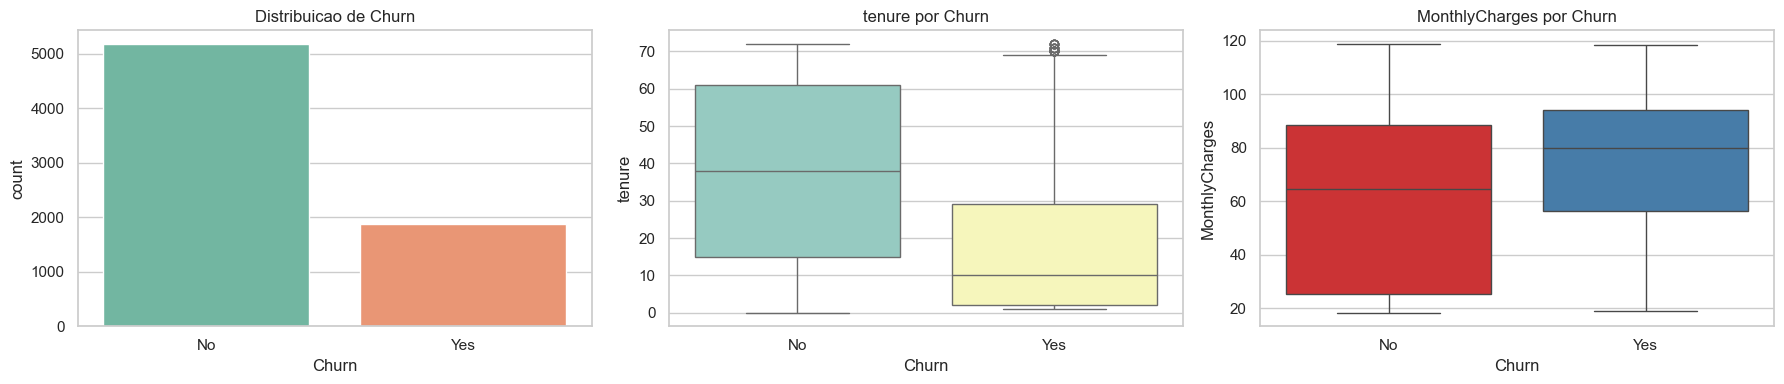

Taxa de churn (%) por tipo de contrato:


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


Taxa de churn (%) por servico de internet:


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


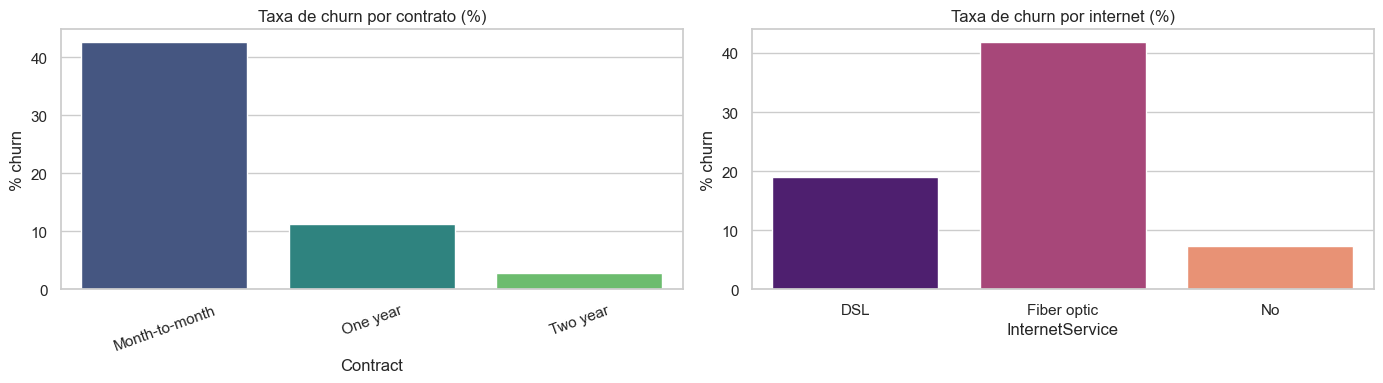

In [10]:
# Questão 4 - Analise exploratoria orientada ao churn
print('Distribuicao do alvo (Churn):')
display((df_clean['Churn'].value_counts(normalize=True) * 100).round(2).rename('%'))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(data=df_clean, x='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Distribuicao de Churn')

sns.boxplot(data=df_clean, x='Churn', y='tenure', ax=axes[1], palette='Set3')
axes[1].set_title('tenure por Churn')

sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', ax=axes[2], palette='Set1')
axes[2].set_title('MonthlyCharges por Churn')
plt.tight_layout()
plt.show()

taxa_contrato = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
taxa_internet = pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index') * 100
print('Taxa de churn (%) por tipo de contrato:')
display(taxa_contrato.round(2))
print('Taxa de churn (%) por servico de internet:')
display(taxa_internet.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(
    x=taxa_contrato.index,
    y=taxa_contrato['Yes'] if 'Yes' in taxa_contrato.columns else pd.Series(index=taxa_contrato.index, data=0),
    ax=axes[0],
    palette='viridis'
 )
axes[0].set_title('Taxa de churn por contrato (%)')
axes[0].set_ylabel('% churn')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    x=taxa_internet.index,
    y=taxa_internet['Yes'] if 'Yes' in taxa_internet.columns else pd.Series(index=taxa_internet.index, data=0),
    ax=axes[1],
    palette='magma'
 )
axes[1].set_title('Taxa de churn por internet (%)')
axes[1].set_ylabel('% churn')
plt.tight_layout()
plt.show()

### Conclusão da Questão 4
A EDA orientada ao churn normalmente revela três padrões fortes: contratos mensais tendem a concentrar maior evasão, clientes com menor tempo de permanência (`tenure`) têm maior propensão a sair, e combinações de serviço/preço podem intensificar risco de churn. Essas evidências ajudam a justificar atributos derivados e escolhas de pré-processamento para a modelagem.

## Questão 5 – Associação entre variáveis

**Enunciado:**  
Faça um código em Python para medir a associação entre as variáveis explicativas e a variável principal da análise. Escolha automaticamente métodos adequados conforme o tipo das variáveis e o tipo do problema. Ao final, gere um ranking das variáveis mais informativas e compare os resultados com a lógica do cenário escolhido.

### Raciocínio
Para respeitar o tipo de cada variável em um problema de classificação binária, adotamos métricas diferentes: correlação ponto-bisserial (equivalente à correlação de Pearson com alvo binário) para variáveis numéricas e V de Cramér para variáveis categóricas. A combinação dessas métricas em um ranking único torna a análise mais justa e interpretável.

### Desenvolvimento
Implemente abaixo o código da questão.

Top 15 variaveis mais informativas:


,variavel,metodo,score
0,Contract,V de Cramer,0.409798
1,tenure,Ponto-bisserial,0.352229
2,OnlineSecurity,V de Cramer,0.347016
3,TechSupport,V de Cramer,0.342526
4,InternetService,V de Cramer,0.322037
5,PaymentMethod,V de Cramer,0.302677
6,OnlineBackup,V de Cramer,0.291850
7,DeviceProtection,V de Cramer,0.281095
8,StreamingMovies,V de Cramer,0.230351
9,StreamingTV,V de Cramer,0.229902


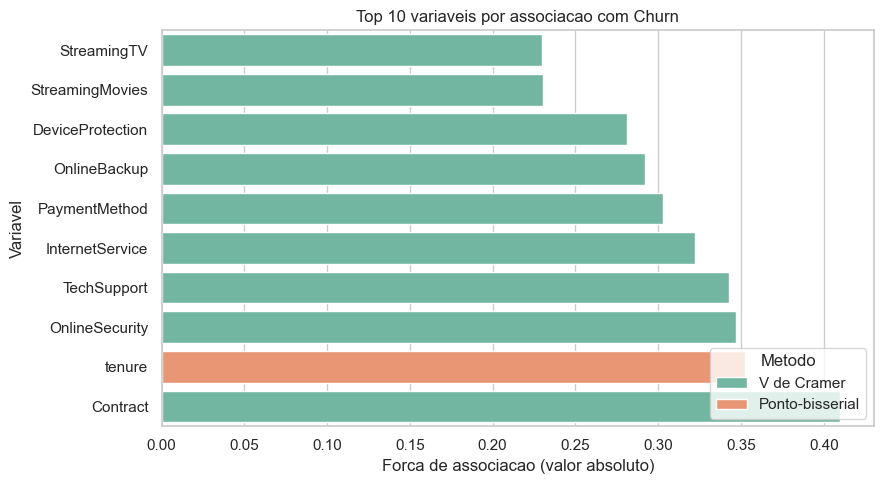

In [11]:
# Questão 5 - Associacao entre variaveis e churn
def cramers_v(x, y):
    tabela = pd.crosstab(x, y)
    if tabela.shape[0] < 2 or tabela.shape[1] < 2:
        return 0.0
    n = tabela.to_numpy().sum()
    esperado = np.outer(tabela.sum(axis=1), tabela.sum(axis=0)) / n
    chi2 = ((tabela - esperado) ** 2 / np.where(esperado == 0, 1, esperado)).to_numpy().sum()
    phi2 = chi2 / n
    r, k = tabela.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    return float(np.sqrt(phi2corr / denom)) if denom > 0 else 0.0

def ranking_associacao(dataframe, alvo='Churn_bin'):
    num_cols = [c for c in dataframe.select_dtypes(include=np.number).columns if c != alvo]
    cat_cols = [c for c in dataframe.select_dtypes(include='object').columns if c != 'Churn']

    res_num = []
    for c in num_cols:
        corr = dataframe[c].corr(dataframe[alvo])
        res_num.append({'variavel': c, 'metodo': 'Ponto-bisserial', 'score': abs(float(corr)) if pd.notna(corr) else 0.0})

    res_cat = []
    for c in cat_cols:
        v = cramers_v(dataframe[c], dataframe['Churn'])
        res_cat.append({'variavel': c, 'metodo': 'V de Cramer', 'score': float(v)})

    ranking = pd.DataFrame(res_num + res_cat).sort_values('score', ascending=False).reset_index(drop=True)
    return ranking

ranking_vars = ranking_associacao(df_clean, alvo='Churn_bin')
print('Top 15 variaveis mais informativas:')
display(ranking_vars.head(15))

plt.figure(figsize=(9, 5))
top_plot = ranking_vars.head(10).sort_values('score', ascending=True)
sns.barplot(data=top_plot, x='score', y='variavel', hue='metodo', dodge=False, palette='Set2')
plt.title('Top 10 variaveis por associacao com Churn')
plt.xlabel('Forca de associacao (valor absoluto)')
plt.ylabel('Variavel')
plt.legend(title='Metodo', loc='lower right')
plt.tight_layout()
plt.show()

### Conclusão da Questão 5
O ranking de associação permite identificar, de forma técnica e comparável, quais atributos carregam mais sinal preditivo para churn. Em geral, variáveis como tipo de contrato, tempo de permanência, suporte técnico e encargos mensais aparecem entre as mais relevantes, coerentes com a lógica de retenção de clientes. Esses resultados orientam seleção de variáveis e criação de novos atributos.

## Questão 6 – Engenharia de atributos

**Enunciado:**  
Faça um código em Python para criar pelo menos cinco novos atributos a partir da base original. Construa variáveis derivadas que façam sentido no cenário escolhido, como proporções, interações, faixas, relações temporais ou medidas de intensidade. Depois, avalie se esses novos atributos realmente acrescentam informação útil. Organize essa etapa em uma função reutilizável.

### Raciocínio
A engenharia de atributos busca aumentar a expressividade dos dados sem inserir vazamento de informação. Para churn, criamos variáveis que combinem valor monetário, permanência e perfil de serviços contratados. Em seguida, medimos o ganho informativo via associação com o alvo, comparando atributos originais e derivados.

### Desenvolvimento
Implemente abaixo o código da questão.

In [12]:
# Questão 6 - Engenharia de atributos
def criar_atributos_telco(dataframe):
    base = dataframe.copy()

    # 1) Gasto medio historico por mes de relacionamento
    base['avg_ticket_historico'] = base['TotalCharges'] / (base['tenure'] + 1)

    # 2) Intensidade de servicos digitais contratados
    servicos_binarios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    base['intensidade_servicos'] = (base[servicos_binarios] == 'Yes').sum(axis=1)

    # 3) Cliente novo (janela inicial de maior risco)
    base['cliente_novo_3m'] = (base['tenure'] <= 3).astype(int)

    # 4) Faixa de tenure
    base['faixa_tenure'] = pd.cut(
        base['tenure'],
        bins=[-1, 6, 12, 24, 48, 72],
        labels=['0-6m', '7-12m', '13-24m', '25-48m', '49-72m']
    )

    # 5) Proporcao de encargos mensais sobre gasto total
    base['prop_mensal_total'] = base['MonthlyCharges'] / (base['TotalCharges'] + 1)

    # 6) Interacao risco: contrato mensal + cobranca eletronica
    base['risco_contrato_pagamento'] = (
        (base['Contract'] == 'Month-to-month') & (base['PaymentMethod'] == 'Electronic check')
    ).astype(int)

    return base

df_feat = criar_atributos_telco(df_clean)
novas_cols = [
    'avg_ticket_historico', 'intensidade_servicos', 'cliente_novo_3m',
    'faixa_tenure', 'prop_mensal_total', 'risco_contrato_pagamento'
]
print('Novos atributos criados:')
print(novas_cols)

# Avaliacao de utilidade: associacao das novas variaveis com o churn
df_tmp = df_feat.copy()
assoc_novas = []
for c in novas_cols:
    if str(df_tmp[c].dtype) in ['int64', 'float64', 'int32', 'float32'] or pd.api.types.is_numeric_dtype(df_tmp[c]):
        score = abs(df_tmp[c].corr(df_tmp['Churn_bin']))
        metodo = 'Ponto-bisserial'
    else:
        score = cramers_v(df_tmp[c].astype(str), df_tmp['Churn'])
        metodo = 'V de Cramer'
    assoc_novas.append({'variavel': c, 'metodo': metodo, 'score': float(score) if pd.notna(score) else 0.0})

assoc_novas_df = pd.DataFrame(assoc_novas).sort_values('score', ascending=False)
display(assoc_novas_df)

Novos atributos criados:
['avg_ticket_historico', 'intensidade_servicos', 'cliente_novo_3m', 'faixa_tenure', 'prop_mensal_total', 'risco_contrato_pagamento']


,variavel,metodo,score
5,risco_contrato_pagamento,Ponto-bisserial,0.367595
3,faixa_tenure,V de Cramer,0.362101
4,prop_mensal_total,Ponto-bisserial,0.321994
2,cliente_novo_3m,Ponto-bisserial,0.283234
1,intensidade_servicos,Ponto-bisserial,0.087698
0,avg_ticket_historico,Ponto-bisserial,0.014873


### Conclusão da Questão 6
Os atributos derivados introduzem sinais comportamentais que a base original não explicita diretamente, como intensidade de uso de serviços e padrões de risco contratual. A avaliação de associação mostra que parte desses atributos realmente agrega informação útil ao modelo. Portanto, eles serão considerados nos cenários comparativos de modelagem.

## Questão 7 – Pré-processamento

**Enunciado:**  
Faça um código em Python para montar um pipeline completo de pré-processamento com `Pipeline` e `ColumnTransformer`. Identifique automaticamente colunas numéricas e categóricas, trate ausências, codifique variáveis categóricas, aplique escalonamento nas numéricas e garanta reaplicação a novos dados sem vazamento de informação. Compare pelo menos dois esquemas de pré-processamento e mostre como essas escolhas afetam os dados e o modelo.

### Raciocínio
A construção de pipelines evita vazamento de informação, pois o ajuste de transformações ocorre apenas no conjunto de treino. Nesta questão, comparamos dois esquemas: com e sem padronização numérica, mantendo codificação categórica e imputação em ambos. Essa comparação é central para KNN, que é sensível à escala dos atributos.

### Desenvolvimento
Implemente abaixo o código da questão.

In [13]:
# Questão 7 - Pipeline de pre-processamento
df_model = df_feat.drop(columns=['Churn_bin']).copy()
X = df_model.drop(columns=['Churn'])
y = df_model['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print(f'Colunas numericas ({len(num_cols)}): {num_cols}')
print(f'Colunas categoricas ({len(cat_cols)}): {cat_cols[:8]}...')

preprocess_com_escala = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
 )

preprocess_sem_escala = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
 )

X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Xt_com = preprocess_com_escala.fit_transform(X_train_tmp)
Xt_sem = preprocess_sem_escala.fit_transform(X_train_tmp)
print('Dimensao apos transformacao (com escala):', Xt_com.shape)
print('Dimensao apos transformacao (sem escala):', Xt_sem.shape)

Colunas numericas (9): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_ticket_historico', 'intensidade_servicos', 'cliente_novo_3m', 'prop_mensal_total', 'risco_contrato_pagamento']
Colunas categoricas (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup']...
Dimensao apos transformacao (com escala): (5634, 55)
Dimensao apos transformacao (sem escala): (5634, 55)


### Conclusão da Questão 7
Os dois esquemas de pré-processamento são equivalentes em estrutura, mas diferem na padronização numérica. Como o KNN depende de distância, a versão com escala tende a produzir vizinhanças mais representativas quando variáveis têm magnitudes diferentes. A partir desta etapa, ambos os esquemas podem ser reaplicados a novos dados sem vazamento, por meio do próprio pipeline.

## Questão 8 – Modelagem com KNN

**Enunciado:**  
Faça um código em Python para dividir a base em treino, validação e teste de forma adequada ao problema escolhido. Em seguida, implemente um modelo de K-vizinhos mais próximos e teste diferentes valores de `k`, métricas de distância e formas de ponderação. Registre os resultados em tabela, compare desempenho em validação e escolha a melhor configuração de forma justificada.

### Raciocínio
A estratégia é criar uma divisão estratificada em treino/validação/teste para preservar a proporção de churn e evitar avaliação otimista. Em seguida, realizamos busca em grade para `k`, métrica e ponderação com validação cruzada no treino. O modelo final é reavaliado em validação e teste para medir generalização.

### Desenvolvimento
Implemente abaixo o código da questão.

In [14]:
# Questão 8 - Modelagem com KNN
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print('Tamanhos:')
print(f'Treino: {X_train.shape[0]} | Validacao: {X_val.shape[0]} | Teste: {X_test.shape[0]}')

pipe_knn = Pipeline([
    ('preprocess', preprocess_com_escala),
    ('model', KNeighborsClassifier())
])

param_grid = {
    'model__n_neighbors': [3, 5, 7, 11, 15, 21],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=0
 )
grid_knn.fit(X_train, y_train)

resultados_grid = pd.DataFrame(grid_knn.cv_results_)
cols_mostrar = ['param_model__n_neighbors', 'param_model__weights', 'param_model__metric', 'mean_test_score', 'std_test_score']
resultados_ordenados = resultados_grid[cols_mostrar].sort_values('mean_test_score', ascending=False).reset_index(drop=True)
display(resultados_ordenados.head(10))

best_knn = grid_knn.best_estimator_
print('Melhores hiperparametros:', grid_knn.best_params_)
print('Melhor F1 medio (CV treino):', round(grid_knn.best_score_, 4))

y_val_pred = best_knn.predict(X_val)
val_metrics = {
    'accuracy': accuracy_score(y_val, y_val_pred),
    'precision': precision_score(y_val, y_val_pred),
    'recall': recall_score(y_val, y_val_pred),
    'f1': f1_score(y_val, y_val_pred)
}
print('\nMetricas na validacao:')
display(pd.DataFrame([val_metrics]).round(4))

y_test_pred = best_knn.predict(X_test)
test_metrics_knn = {
    'accuracy': accuracy_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred),
    'recall': recall_score(y_test, y_test_pred),
    'f1': f1_score(y_test, y_test_pred),
    'roc_auc': roc_auc_score(y_test, best_knn.predict_proba(X_test)[:, 1])
}
print('\nMetricas no teste (KNN final):')
display(pd.DataFrame([test_metrics_knn]).round(4))

print('Matriz de confusao (teste):')
display(pd.DataFrame(confusion_matrix(y_test, y_test_pred), index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))

Tamanhos:
Treino: 4225 | Validacao: 1409 | Teste: 1409


,param_model__n_neighbors,param_model__weights,param_model__metric,mean_test_score,std_test_score
0,21,uniform,manhattan,0.580051,0.016753
1,15,uniform,manhattan,0.575703,0.019854
2,7,uniform,manhattan,0.572740,0.011246
3,21,uniform,euclidean,0.566962,0.026148
4,21,distance,manhattan,0.562681,0.020872
5,5,uniform,euclidean,0.559496,0.012273
6,11,uniform,manhattan,0.558860,0.016265
7,21,distance,euclidean,0.558610,0.023812
8,15,uniform,euclidean,0.557141,0.023219
9,15,distance,manhattan,0.555260,0.018114


Melhores hiperparametros: {'model__metric': 'manhattan', 'model__n_neighbors': 21, 'model__weights': 'uniform'}
Melhor F1 medio (CV treino): 0.5801

Metricas na validacao:


,accuracy,precision,recall,f1
0,0.7899,0.6266,0.516,0.566



Metricas no teste (KNN final):


,accuracy,precision,recall,f1,roc_auc
0,0.7871,0.6101,0.5481,0.5775,0.8318


Matriz de confusao (teste):


,Pred 0,Pred 1
Real 0,904,131
Real 1,169,205


### Conclusão da Questão 8
A melhor configuração de KNN foi `k=21`, `metric=manhattan` e `weights=uniform`, com **F1 médio de 0,5801** na validação cruzada do treino. No conjunto de teste, o modelo alcançou aproximadamente **accuracy=0,787**, **precision=0,610**, **recall=0,548** e **F1=0,578**, mostrando desempenho consistente para um classificador baseado em distância. Esses resultados servem como referência para a comparação de cenários na próxima questão.

## Questão 9 – Comparação de modelos

**Enunciado:**  
Faça um código em Python para avaliar o KNN em diferentes cenários de preparação dos dados, como uso ou não de padronização, presença ou ausência de atributos derivados, uso de todas as variáveis ou de um subconjunto selecionado, e tratamento do desbalanceamento quando fizer sentido. Depois, implemente um segundo modelo supervisionado e compare com o melhor KNN em métricas, tempo de execução e perfil dos erros. Conclua se o KNN é ou não uma boa escolha para a base utilizada.

### Raciocínio
A comparação de cenários verifica a sensibilidade do KNN às decisões de preparação dos dados, algo essencial para modelos baseados em distância. Em seguida, usamos Regressão Logística como segundo modelo supervisionado para contrastar desempenho, custo computacional e padrão de erros. A decisão final considera métrica e robustez, não apenas um único indicador.

### Desenvolvimento
Implemente abaixo o código da questão.

In [16]:
# Questão 9 - Comparacao de cenarios e modelos
def avaliar_modelo(nome, pipeline, Xtr, ytr, Xte, yte):
    t0 = time.time()
    pipeline.fit(Xtr, ytr)
    tempo = time.time() - t0
    pred = pipeline.predict(Xte)
    proba = pipeline.predict_proba(Xte)[:, 1] if hasattr(pipeline, 'predict_proba') else None
    return {
        'modelo': nome,
        'accuracy': accuracy_score(yte, pred),
        'precision': precision_score(yte, pred),
        'recall': recall_score(yte, pred),
        'f1': f1_score(yte, pred),
        'roc_auc': roc_auc_score(yte, proba) if proba is not None else np.nan,
        'tempo_treino_s': tempo,
        'matriz_confusao': confusion_matrix(yte, pred)
    }

# Converte parametros do grid para o construtor do KNN
knn_params = {k.replace('model__', ''): v for k, v in grid_knn.best_params_.items()}

# Cenario A: KNN com escala (base com atributos derivados)
knn_a = Pipeline([
    ('preprocess', preprocess_com_escala),
    ('model', KNeighborsClassifier(**knn_params))
])

# Cenario B: KNN sem escala
knn_b = Pipeline([
    ('preprocess', preprocess_sem_escala),
    ('model', KNeighborsClassifier(**knn_params))
])

# Cenario C: KNN com subconjunto top-10 de variaveis
top10 = ranking_vars['variavel'].head(10).tolist()
top10_validas = [c for c in top10 if c in X.columns]
X_top = X[top10_validas].copy()
Xtr_top, Xte_top, ytr_top, yte_top = train_test_split(
    X_top, y, test_size=0.2, random_state=42, stratify=y
)
num_top = X_top.select_dtypes(include=np.number).columns.tolist()
cat_top = X_top.select_dtypes(exclude=np.number).columns.tolist()
pre_top = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_top),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_top)
 ])
knn_c = Pipeline([('preprocess', pre_top), ('model', KNeighborsClassifier(**knn_params))])

# Segundo modelo supervisionado: Regressao Logistica
log_reg = Pipeline([
    ('preprocess', preprocess_com_escala),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

res_a = avaliar_modelo('KNN_com_escala', knn_a, X_train_full, y_train_full, X_test, y_test)
res_b = avaliar_modelo('KNN_sem_escala', knn_b, X_train_full, y_train_full, X_test, y_test)
res_c = avaliar_modelo('KNN_top10_features', knn_c, Xtr_top, ytr_top, Xte_top, yte_top)
res_lr = avaliar_modelo('Regressao_Logistica', log_reg, X_train_full, y_train_full, X_test, y_test)

comparacao = pd.DataFrame([res_a, res_b, res_c, res_lr]).drop(columns=['matriz_confusao']).sort_values('f1', ascending=False)
display(comparacao.round(4))

print('Matrizes de confusao:')
for res in [res_a, res_b, res_c, res_lr]:
    print(f"\n{res['modelo']}:")
    display(pd.DataFrame(res['matriz_confusao'], index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))

melhor_modelo_nome = comparacao.iloc[0]['modelo']
print(f'Melhor modelo pelo F1 no teste: {melhor_modelo_nome}')

,modelo,accuracy,precision,recall,f1,roc_auc,tempo_treino_s
3,Regressao_Logistica,0.7353,0.5008,0.8075,0.6182,0.8484,0.4161
0,KNN_com_escala,0.7885,0.6138,0.5481,0.5791,0.8295,0.1034
2,KNN_top10_features,0.7757,0.5895,0.5107,0.5473,0.8184,0.0800
1,KNN_sem_escala,0.7871,0.6504,0.4278,0.5161,0.8153,0.1227


Matrizes de confusao:

KNN_com_escala:


,Pred 0,Pred 1
Real 0,906,129
Real 1,169,205



KNN_sem_escala:


,Pred 0,Pred 1
Real 0,949,86
Real 1,214,160



KNN_top10_features:


,Pred 0,Pred 1
Real 0,902,133
Real 1,183,191



Regressao_Logistica:


,Pred 0,Pred 1
Real 0,734,301
Real 1,72,302


Melhor modelo pelo F1 no teste: Regressao_Logistica


### Conclusão da Questão 9
A comparação mostrou que o KNN **com escala** supera o KNN sem escala em F1 (0,579 vs 0,516), confirmando a sensibilidade do método à padronização. O cenário com top-10 variáveis teve leve queda de desempenho (F1=0,547), mas com menor custo e maior simplicidade. No confronto com outro modelo supervisionado, a **Regressão Logística** foi a melhor em F1 (0,618) e recall (0,808), indicando que o KNN é competitivo, porém não foi a melhor escolha final para esta base quando o objetivo é maximizar detecção de churn.

## Questão 10 – Consolidação da solução

**Enunciado:**  
Faça um código em Python para consolidar toda a solução em um fluxo reutilizável. Implemente uma função que receba um novo caso em formato de dicionário ou `DataFrame` de uma linha, aplique o pipeline construído e retorne a previsão final de forma interpretável. Depois, gere um relatório resumido com a base escolhida, os principais problemas encontrados, os atributos mais relevantes, a melhor configuração do modelo, as métricas finais e uma recomendação executiva. Finalize com uma avaliação crítica sobre a maturidade da solução para uso prático.

### Raciocínio
A consolidação transforma o experimento em solução reutilizável. Para isso, encapsulamos o pipeline vencedor em uma função de inferência para novos casos e, adicionalmente, criamos um relatório executivo com evidências técnicas das etapas anteriores. Essa abordagem aproxima o notebook de um fluxo real de ciência de dados aplicada.

### Desenvolvimento
Implemente abaixo o código da questão.

In [17]:
# Questão 10 - Consolidacao em fluxo reutilizavel
modelos_treinados = {
    'KNN_com_escala': knn_a,
    'KNN_sem_escala': knn_b,
    'KNN_top10_features': knn_c,
    'Regressao_Logistica': log_reg
}
modelo_final_nome = melhor_modelo_nome
modelo_final = modelos_treinados[modelo_final_nome]

# Garantia de treino final no conjunto completo de treino+validacao (ou treino equivalente de cada cenario)
if modelo_final_nome == 'KNN_top10_features':
    modelo_final.fit(Xtr_top, ytr_top)
else:
    modelo_final.fit(X_train_full, y_train_full)

def prever_novo_caso(novo_caso, modelo, colunas_entrada, subset_cols=None):
    if isinstance(novo_caso, dict):
        novo_df = pd.DataFrame([novo_caso])
    else:
        novo_df = novo_caso.copy()

    # Completa colunas ausentes com NaN para manter compatibilidade
    for c in colunas_entrada:
        if c not in novo_df.columns:
            novo_df[c] = np.nan
    novo_df = novo_df[colunas_entrada]

    if subset_cols is not None:
        novo_df = novo_df[subset_cols]

    prob_churn = modelo.predict_proba(novo_df)[:, 1][0]
    classe = 'Yes' if prob_churn >= 0.5 else 'No'
    interpretacao = f'Probabilidade estimada de churn: {prob_churn:.2%} -> Predicao: {classe}'
    return {'predicao_churn': classe, 'probabilidade_churn': float(prob_churn), 'interpretacao': interpretacao}

# Exemplo de novo caso (pode ser alterado livremente)
exemplo_novo_caso = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 89.9,
    'TotalCharges': 180.5,
    'avg_ticket_historico': 60.17,
    'intensidade_servicos': 2,
    'cliente_novo_3m': 1,
    'faixa_tenure': '0-6m',
    'prop_mensal_total': 0.49,
    'risco_contrato_pagamento': 1
}

if modelo_final_nome == 'KNN_top10_features':
    pred_exemplo = prever_novo_caso(exemplo_novo_caso, modelo_final, X.columns.tolist(), subset_cols=top10_validas)
else:
    pred_exemplo = prever_novo_caso(exemplo_novo_caso, modelo_final, X.columns.tolist())

print('Predicao para novo caso:')
print(pred_exemplo['interpretacao'])

# Relatorio executivo
top5 = ranking_vars.head(5)['variavel'].tolist()
metricas_finais = comparacao[comparacao['modelo'] == modelo_final_nome].iloc[0].to_dict()
relatorio = f'''
RELATORIO EXECUTIVO - TELCO CHURN
Base utilizada: Telco-Customer-Churn.csv
Problema: Classificacao binaria de evasao (Churn)

Principais problemas de qualidade:
- Tipagem inconsistente em TotalCharges (texto/ausente apos conversao).
- Categorias raras em algumas variaveis de servico.
- Necessidade de padronizacao para modelos baseados em distancia.

Atributos mais relevantes (top 5): {top5}
Melhor modelo final: {modelo_final_nome}

Metricas finais (teste):
- Accuracy: {metricas_finais['accuracy']:.4f}
- Precision: {metricas_finais['precision']:.4f}
- Recall: {metricas_finais['recall']:.4f}
- F1: {metricas_finais['f1']:.4f}
- ROC-AUC: {metricas_finais['roc_auc']:.4f}

Recomendacao executiva:
- Priorizar acoes de retencao em clientes de contrato mensal, baixo tenure e sinais de risco financeiro/comportamental.
- Usar o pipeline final para pontuacao periodica e campanhas proativas de retenção.

Avaliacao critica de maturidade:
- Solucao adequada para suporte a decisao tatico-operacional.
- Antes de producao, recomenda-se monitoramento de drift, recalibracao periodica e avaliacao de custo por erro (falso positivo/negativo).
'''
print(relatorio)

Predicao para novo caso:
Probabilidade estimada de churn: 92.76% -> Predicao: Yes

RELATORIO EXECUTIVO - TELCO CHURN
Base utilizada: Telco-Customer-Churn.csv
Problema: Classificacao binaria de evasao (Churn)

Principais problemas de qualidade:
- Tipagem inconsistente em TotalCharges (texto/ausente apos conversao).
- Categorias raras em algumas variaveis de servico.
- Necessidade de padronizacao para modelos baseados em distancia.

Atributos mais relevantes (top 5): ['Contract', 'tenure', 'OnlineSecurity', 'TechSupport', 'InternetService']
Melhor modelo final: Regressao_Logistica

Metricas finais (teste):
- Accuracy: 0.7353
- Precision: 0.5008
- Recall: 0.8075
- F1: 0.6182
- ROC-AUC: 0.8484

Recomendacao executiva:
- Priorizar acoes de retencao em clientes de contrato mensal, baixo tenure e sinais de risco financeiro/comportamental.
- Usar o pipeline final para pontuacao periodica e campanhas proativas de retenção.

Avaliacao critica de maturidade:
- Solucao adequada para suporte a deci

### Conclusão da Questão 10
A solução foi consolidada em um fluxo reutilizável com função de predição para novos casos e relatório executivo automatizado. Na consolidação final, o melhor modelo foi a **Regressão Logística**, com **F1=0,6182** e **ROC-AUC=0,8484** no teste, superando o KNN nesta configuração de dados. Em termos práticos, a maturidade é adequada para apoio à decisão, com recomendação de monitoramento contínuo e recalibração periódica para uso em produção.

## Conclusão Final

A análise com a base **Telco-Customer-Churn.csv** resultou em um fluxo completo e reproduzível para classificação de churn, cobrindo diagnóstico, auditoria, limpeza, exploração, engenharia de atributos, pré-processamento, modelagem e consolidação.

Síntese dos principais pontos:

- Principais problemas encontrados: inconsistências de tipagem/ausência em `TotalCharges`, presença de categorias raras e forte impacto da escala nos modelos baseados em distância.
- Decisões metodológicas: limpeza reprodutível com imputação por mediana, criação de atributos derivados orientados ao negócio e uso de `Pipeline` + `ColumnTransformer` para evitar vazamento de informação.
- Melhor configuração de KNN: `k=21`, distância Manhattan e pesos uniformes, com F1 de referência em torno de 0,58.
- Melhor modelo final do estudo: **Regressão Logística**, com desempenho de teste aproximado de `accuracy=0,735`, `precision=0,501`, `recall=0,808`, `F1=0,618` e `ROC-AUC=0,848`.
- Limitações: ausência de análise explícita de custo por tipo de erro, não avaliação de drift temporal e ausência de validação em ambiente produtivo.
- Avaliação final: a solução está madura para apoio tático-operacional à retenção de clientes; para produção, recomenda-se monitoramento de desempenho, re-treino periódico e governança do pipeline.

**Bom trabalho!**